In [ ]:
import pandas as pd
import requests
import json

#usgs api address for lake level data
usgs_url = "https://waterservices.usgs.gov/nwis/dv/"

usgs_params = {
    "format": "json",    # we want it returned in json
    "sites": "10010000",    # Great Salt Lake at Saltair Boat Harbor, UT - USGS-10010000
    "parameterCd": "62614",   # code for lake water surface elevation
    "startDT": "1950-01-01",   # start and end dates
    "endDT": "2024-12-31"
}

#getting data from the api address with the params we set above
usgs_response = requests.get(usgs_url, params=usgs_params)
#converting to json
usgs_data = usgs_response.json()

# save the full json to a file for viewing/searching
with open("usgs_response.json", "w") as f:
    json.dump(usgs_data, f, indent=2)


In [4]:
# entering the layers where the data lives, grabbing the first value in each list
usgs_time_series = usgs_data["value"]["timeSeries"][0]["values"][0]["value"]

# converting to pandas dataframe
usgs_df = pd.DataFrame(usgs_time_series)

# data exploration
print(usgs_df.head(20))
print(usgs_df.shape)

      value qualifiers                 dateTime
0   4197.15        [A]  1950-01-01T00:00:00.000
1   4197.40        [A]  1950-02-01T00:00:00.000
2   4197.90        [A]  1950-03-01T00:00:00.000
3   4198.15        [A]  1950-04-01T00:00:00.000
4   4198.35        [A]  1950-05-01T00:00:00.000
5   4198.80        [A]  1950-06-01T00:00:00.000
6   4198.65        [A]  1950-07-01T00:00:00.000
7   4198.30        [A]  1950-08-01T00:00:00.000
8   4197.90        [A]  1950-09-01T00:00:00.000
9   4197.55        [A]  1950-10-01T00:00:00.000
10  4197.60        [A]  1950-11-01T00:00:00.000
11  4197.90        [A]  1950-12-01T00:00:00.000
12  4198.30        [A]  1951-01-01T00:00:00.000
13  4198.50        [A]  1951-02-01T00:00:00.000
14  4198.95        [A]  1951-03-01T00:00:00.000
15  4199.20        [A]  1951-04-01T00:00:00.000
16  4199.45        [A]  1951-05-01T00:00:00.000
17  4199.90        [A]  1951-06-01T00:00:00.000
18  4199.55        [A]  1951-07-01T00:00:00.000
19  4199.15        [A]  1951-08-01T00:00

In [ ]:
# cleaning up the dataframe
usgs_df = usgs_df.rename(columns={"dateTime": "date", "value": "elevation_ft"})
usgs_df = usgs_df.drop(columns=["qualifiers"])

# converting the date columns to datetime datatype
usgs_df["date"] = pd.to_datetime(usgs_df["date"])

# converting the string elevation data to numeric
usgs_df["elevation_ft"] = pd.to_numeric(usgs_df["elevation_ft"], errors="coerce")

# aggregating to monthly measurements
# setting the date as the index, grouping by month ("MS" = month start), taking the average of each month, reset the index
usgs_monthly = usgs_df.set_index("date").resample("MS")["elevation_ft"].mean().reset_index()

# adding some separate date columns for potential later use
usgs_monthly["year"] = usgs_monthly["date"].dt.year
usgs_monthly["month"] = usgs_monthly["date"].dt.month

usgs_monthly.to_csv('lake_level_monthly.csv', index=False)

usgs_monthly

,date,elevation_ft,year,month
0,1950-01-01,4197.150000,1950,1
1,1950-02-01,4197.400000,1950,2
2,1950-03-01,4197.900000,1950,3
3,1950-04-01,4198.150000,1950,4
4,1950-05-01,4198.350000,1950,5
...,...,...,...,...
895,2024-08-01,4193.232258,2024,8
896,2024-09-01,4192.660000,2024,9
897,2024-10-01,4192.316129,2024,10
898,2024-11-01,4192.183333,2024,11


In [35]:
usgs_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          900 non-null    datetime64[ns]
 1   elevation_ft  900 non-null    float64       
 2   year          900 non-null    int32         
 3   month         900 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 21.2 KB


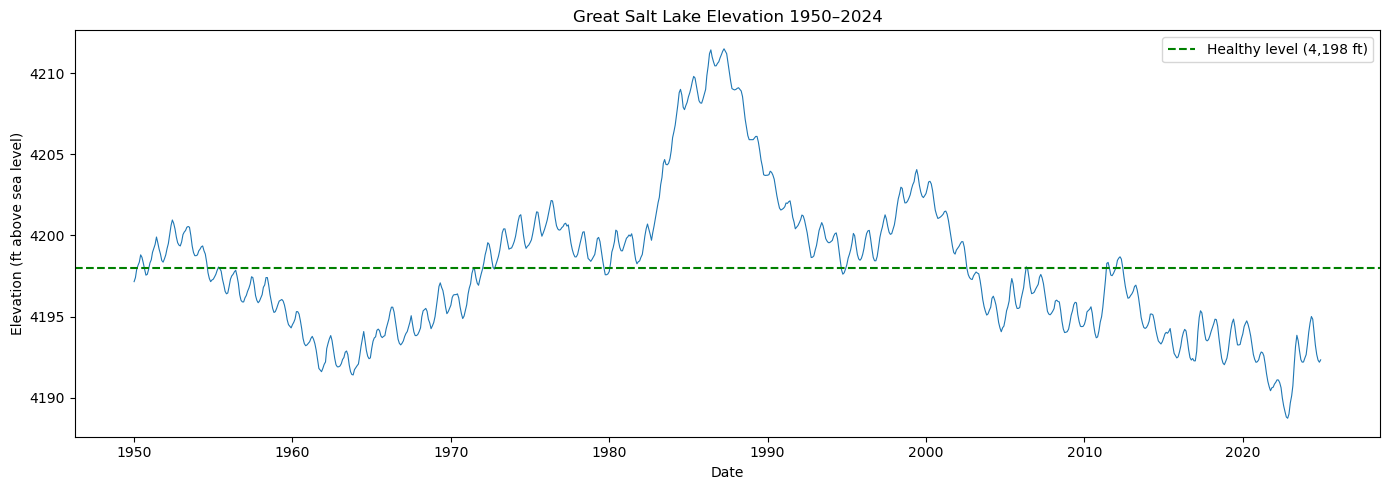

In [ ]:
import matplotlib.pyplot as plt

# plotting lake elevation over time

plt.figure(figsize=(14, 5))
plt.plot(usgs_monthly["date"], usgs_monthly["elevation_ft"], linewidth=0.8)
plt.axhline(y=4198, color="green", linestyle="--", label="Healthy level (4,198 ft)")
plt.title("Great Salt Lake Elevation 1950–2024")
plt.ylabel("Elevation (ft above sea level)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# using time library to add a pause between API requests so we didn't get blocked
import time

# turns out there is a newer version of the API than we reference in our proposal
# https://www.ncei.noaa.gov/cdo-web/api/v2 is the older version and has now been deprecated
# the newer version below does not require an access token

url = "https://www.ncei.noaa.gov/access/services/data/v1"


# NOAA only allows one year per data request, 
# so going to loop through every year from 1950-2025 and gather each years data into this empty list
all_data = []

for year in range(1950, 2025):
    params = {
        "dataset": "daily-summaries",
        "stations": "USW00024127",  # SLC airport station code
        "dataTypes": "PRCP", # precipitation data
        "startDate": f"{year}-01-01",   # inserting the current year for each loops date parameters
        "endDate": f"{year}-12-31",
        "format": "json",
        "units": "standard"
    }
    
    # sends the request
    response = requests.get(url, params=params)
    
    # checking if the request succeeded (code = 200) and if so converting the response to json data
    if response.status_code == 200:
        data = response.json()
        # adding data from successful responses, flagging any that didn't work
        if data:
            all_data.extend(data)
            print(f"{year}: got {len(data)} records")
        else:
            print(f"{year}: no results")
    else:
        print(f"{year}: error {response.status_code} - {response.text[:100]}")

    # adding a delay to abide by API rules
    time.sleep(0.2)

precip_df = pd.DataFrame(all_data)
print(precip_df.head())
print(precip_df.columns)



1950: got 365 records
1951: got 365 records
1952: got 366 records
1953: got 365 records
1954: got 365 records
1955: got 365 records
1956: got 366 records
1957: got 365 records
1958: got 365 records
1959: got 365 records
1960: got 366 records
1961: got 365 records
1962: got 365 records
1963: got 365 records
1964: got 366 records
1965: got 365 records
1966: got 365 records
1967: got 365 records
1968: got 366 records
1969: got 365 records
1970: got 365 records
1971: got 365 records
1972: got 366 records
1973: got 365 records
1974: got 365 records
1975: got 365 records
1976: got 366 records
1977: got 365 records
1978: got 365 records
1979: got 365 records
1980: got 366 records
1981: got 365 records
1982: got 365 records
1983: got 365 records
1984: got 366 records
1985: got 365 records
1986: got 365 records
1987: got 365 records
1988: got 366 records
1989: got 365 records
1990: got 365 records
1991: got 365 records
1992: error 503 - <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><

In [ ]:
# cleaning up dataset, similar to NSGS cleaning steps
precip_df = precip_df.rename(columns={"DATE": "date", "PRCP": "precip_inches"})
precip_df["date"] = pd.to_datetime(precip_df["date"])
precip_df["precip_inches"] = pd.to_numeric(precip_df["precip_inches"], errors="coerce")

# resampling to montly precipitation TOTAL (sum)
# note this is different than the lake level aggregation, which was the average measurement (mean)
precip_monthly = precip_df.set_index("date")["precip_inches"].resample("MS").sum().reset_index()
precip_monthly.columns = ["date", "monthly_precip_inches"]

# add year and month columns for potential later use
precip_monthly["year"] = precip_monthly["date"].dt.year
precip_monthly["month"] = precip_monthly["date"].dt.month

# creating CSV
precip_monthly.to_csv("precipitation_monthly.csv", index=False)

precip_monthly


,date,monthly_precip_inches,year,month
0,1950-01-01,1.80,1950,1
1,1950-02-01,1.19,1950,2
2,1950-03-01,0.98,1950,3
3,1950-04-01,1.29,1950,4
4,1950-05-01,2.18,1950,5
...,...,...,...,...
895,2024-08-01,1.15,2024,8
896,2024-09-01,0.42,2024,9
897,2024-10-01,0.79,2024,10
898,2024-11-01,1.22,2024,11


In [31]:
precip_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   900 non-null    datetime64[ns]
 1   monthly_precip_inches  900 non-null    float64       
 2   year                   900 non-null    int32         
 3   month                  900 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 21.2 KB


In [ ]:
import pandas as pd

# converting snowpack csv to dataframe to do some cleaning
snowpack_df = pd.read_csv('snowpack.csv', comment='#', skip_blank_lines=True)

# data cleaning (renaming columns, converting datatypes, adding additional date cols)
snowpack_df = snowpack_df.rename(columns={"Snowbird (766) Snow Water Equivalent (in) Start of Month Values": "snow_water_equiv_in"})
snowpack_df["Date"] = pd.to_datetime(snowpack_df["Date"], format="%b %Y")
snowpack_df["snow_water_equiv_in"] = pd.to_numeric(snowpack_df["snow_water_equiv_in"], errors="coerce")
snowpack_df["year"] = snowpack_df["Date"].dt.year
snowpack_df["month"] = snowpack_df["Date"].dt.month

snowpack_df


,Date,snow_water_equiv_in,year,month
0,1989-09-01,0.0,1989,9
1,1989-10-01,0.0,1989,10
2,1989-11-01,1.9,1989,11
3,1989-12-01,9.4,1989,12
4,1990-01-01,11.0,1990,1
...,...,...,...,...
434,2025-11-01,0.0,2025,11
435,2025-12-01,1.0,2025,12
436,2026-01-01,6.6,2026,1
437,2026-02-01,14.5,2026,2


In [9]:
# back to CSV to have a clean csv
snowpack_df.to_csv('snowpack_monthly.csv')